# Team F1's Linear Regression model

Team members include Patrick, Carter, Jaegeon and Merlin

In [1]:
#importing all the different libraries that we will need for this part. 
#using the erdos_summer_2025 environment

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
"""
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR """
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

Here we pull in the data that will to be used for our predictors and qualifiers.  We can pull from two different csv files, but should be careful that they line up. <br>
The list in the X dataframe should contain all the different columns that we want to use, such as "gap_between_mean" or "circuitType_RACE"

In [ ]:
# xdata = pd.read_csv(r"C:\Users\merli\Documents\ERDOS\erdos_ds_f1\Merlin preview\gaps and circuit type (no DNF).csv")  #or we can use different files for each, but they should be in the right order
xdata = pd.read_csv("gaps and circuit type (cleaned).csv")
ydata = pd.read_csv("Average Local Positions.csv")
xdata2 = pd.read_csv("paceRankStartPositionDeltas_withDNF.csv")


# xdata3 = pd.read_csv("../data_f1db/f1db-races.csv")
# xdata3 = xdata3[["id","courseLength", "turns"]]
# xdata3 = xdata3.rename(columns={"id":"raceId"})

# Combining all the different csv files into one usable dataframe.

xdata = pd.merge(xdata,xdata2, on = "raceId", how = 'inner')
#xdata = pd.merge(xdata,xdata3,on="raceId",how="left")
#xdata = pd.merge(xdata, xdata4, on="raceId", how="left")
#xdata["turnDensity"] = xdata["turns"] / xdata["courseLength"]


#"Bgap_mean","Bgap_average" ,"First_ten_gap", "circuitType_STREET"
X  = xdata[ ["Bgap_median","absGridDelta","circuitType_STREET"]]

X = X.fillna(1000)  #getting rid of any nan variables, and replaces them with 1000, for only a couple NaNs, shouldn't make a big different. 


Y = ydata[ "average_local_position"]  #this is our target, what we are trying to predict, and will use this to test our predictive model. 


X_train,X_test , Y_train, Y_test = train_test_split(X,Y , test_size= 0.2, shuffle=True, random_state= 117)


In [ ]:
Y.describe() #I don't think I need this

count    535.000000
mean       2.399877
std        0.940866
min        0.210526
25%        1.714286
50%        2.333333
75%        3.000000
max        5.666667
Name: average_local_position, dtype: float64

Here we create the pipeline for how our model will be run.  We are using the Linear Regression model, and we are normalizing our predictor values via StandaScalar.

In [ ]:
#create cross-validation sets for model selection
kfold = KFold(n_splits = 4, shuffle=True, random_state=42)

#creating the pipleline for our Model. 

modelPipeline = Pipeline ([
    ('scalar', StandardScaler() ),  #normalizing our features aka the predictors
    ('poly', PolynomialFeatures(degree = 2, 
                                  interaction_only= True,
                                  include_bias= False) 
                                  ),
    ('reg' , LinearRegression())  # this is the model that we are using, which can be anything we want. 
])



Here is where we train the model, making sure not to use any of our testing data.  That would mean there is data leakage. 

In [ ]:

modelPipeline.fit(X_train,Y_train)  #here we are fitting our model with the testing data,  DO NOT INCLUDE THE TEST PARTITIONS




Pipeline(steps=[('scalar', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('reg', LinearRegression())])

### Model Selection: Look at performance on cross-validation sets

In [379]:
rmses = np.zeros(4)
r2_scores = np.zeros(4)

pipe_to_test = pipe2

for i, (train_index, test_index) in enumerate(kfold.split(X_train, Y_train)):
    X_train_train = X_train.iloc[train_index,:]
    Y_train_train = Y_train.iloc[train_index]

    X_holdout = X_train.iloc[test_index,:]
    Y_holdout = Y_train.iloc[test_index]

    pipe_to_test.fit(X_train_train,Y_train_train)

    y_pred = pipe_to_test.predict(X_holdout)

    rmses[i] = root_mean_squared_error(y_pred, Y_holdout)
    r2_scores[i] = r2_score(Y_holdout,y_pred)

print(rmses, rmses.mean())
print(r2_scores, r2_scores.mean())

[0.80929925 0.93198391 0.86946695 0.86900109] 0.8699377994720361
[0.16610522 0.10378438 0.19329344 0.11999562] 0.1457946653268104


## Final Step: Predict on test set (only after final model is chosen)

Now we can use our trained model to make predictions from the testing predictors, and compare them to the actual predictors from the testing set. 

In [ ]:
modelPipeline.fit(X_train,Y_train)

Y_pred = modelPipeline.predict(X_test) 

rmse = root_mean_squared_error(Y_pred, Y_test)
r2 = r2_score(Y_test,Y_pred)

print(np.std(Y_test))


print(f"Root Mean squared error: {rmse}")
print(f"R^2 value : {r2}")

0.9236025076447286
Root Mean squared error: 0.846495189525739
R^2 value : 0.1600009747437885


In [280]:
final = X_test
final["actual"] = Y_test
final["predicted"] = Y_pred
final["delta"] = Y_test - Y_pred

In [267]:
final

,Bgap_median,absGridDelta,circuitType_STREET,actual,predicted
640,135.0,2.700000,False,3.411765,2.642664
613,62.0,1.000000,False,3.375000,2.359998
471,85.5,1.272727,False,3.263158,2.376926
100,158.5,1.230769,False,2.307692,2.268101
244,192.0,1.636364,False,1.692308,2.333738
...,...,...,...,...,...
218,75.5,0.818182,False,3.000000,2.304828
246,206.5,0.000000,False,1.272727,1.849273
478,338.0,2.380952,False,1.714286,2.463781
437,182.5,0.333333,False,2.315789,1.994029


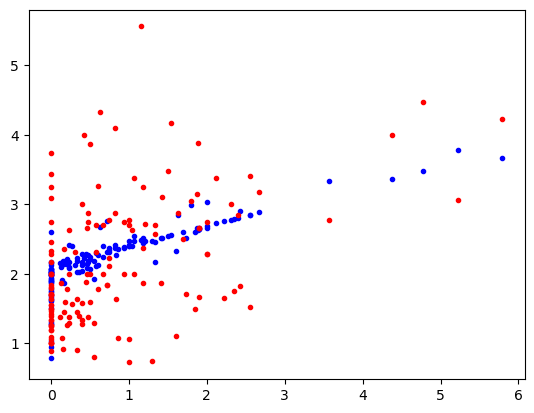

In [341]:
plt.plot(final["absGridDelta"],final["predicted"],'b.')
plt.plot(final["absGridDelta"],final["actual"],'r.')

In [47]:
print(Y_pred[98])
print(X_test.iloc[98,:])
print(Y_test.to_list())

0.9948147530989371
Bgap_median            155.5
circuitType_RACE       False
circuitType_ROAD        True
absGridDelta        2.666667
Name: 571, dtype: object
[3.411764705882353, 3.375, 3.263157894736842, 2.3076923076923075, 1.6923076923076923, 1.4, 1.4545454545454546, 3.25, 2.4615384615384617, 1.818181818181818, 1.0, 1.7777777777777777, 2.7058823529411766, 1.7777777777777777, 2.7, 3.4285714285714284, 1.6923076923076923, 1.4, 3.1, 3.25, 0.7272727272727273, 1.5, 2.2857142857142856, 1.75, 1.5555555555555556, 2.75, 1.5, 2.0, 1.875, 3.7333333333333334, 1.3333333333333333, 2.0, 4.222222222222222, 3.0526315789473686, 3.142857142857143, 1.25, 2.5714285714285716, 1.0, 2.375, 1.0769230769230769, 1.4666666666666666, 1.375, 1.0666666666666669, 2.769230769230769, 1.8, 1.0, 3.473684210526316, 1.5714285714285714, 4.095238095238095, 2.75, 1.375, 1.4285714285714286, 2.0, 1.5555555555555556, 1.8461538461538465, 1.3333333333333333, 2.875, 4.0, 1.2, 1.0588235294117647, 0.9230769230769232, 2.625, 1.6, 1.

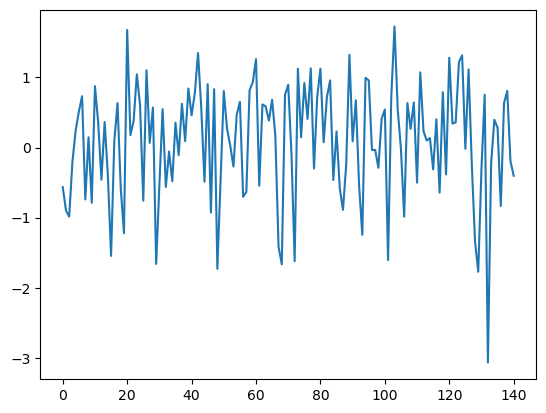

In [335]:
plt.plot((Y_pred- Y_test.to_list()))


In [ ]:
print(modelPipeline.named_steps['reg'].coef_)

[-0.20126872  0.35783612  0.01656983  0.0928313  -0.11807794  0.00636434]


In [ ]:
#Visualize using full data
full = X.copy()

modelPipeline.fit(X,Y)

full["actual"] = Y
full["pred"] = modelPipeline.predict(X)
full["error"] = full["pred"] - full["actual"]
full["index"] = list(range(len(full)))

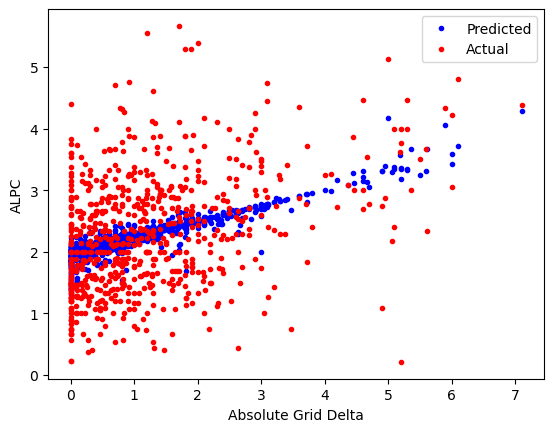

In [399]:
plt.plot(full["absGridDelta"],full["pred"],'b.')
plt.plot(full["absGridDelta"],full["actual"],'r.')
plt.xlabel("Absolute Grid Delta")
plt.ylabel("ALPC")
plt.legend(["Predicted","Actual"])

<Axes: xlabel='absGridDelta', ylabel='pred'>

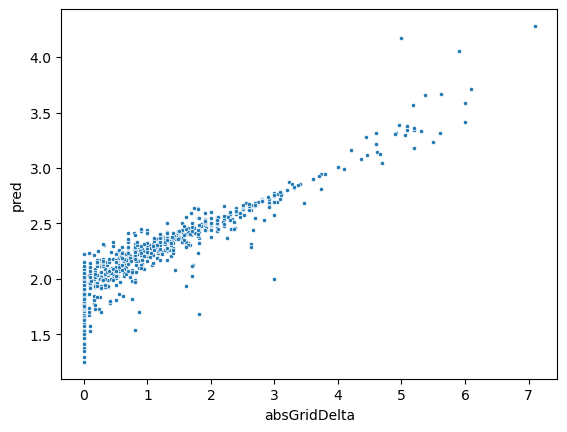

In [397]:
sns.scatterplot(data=full,x="absGridDelta",y="pred",marker=".")

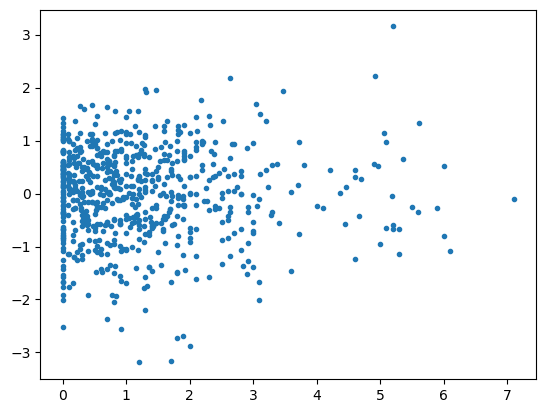

In [355]:
plt.plot(full["absGridDelta"],full["error"],'.')